In [6]:
import pyrtl
from pyrtl.rtllib.libutils import twos_comp_repr
from pyrtl.rtllib.adders import carrysave_adder, kogge_stone
from IPython.display import display, Markdown, display_svg
from graphviz import render
import pyrtl.simulation
from kai.src.float8 import Float8

# Brain Float 16 (BF16) Format


BF16 is a 16-bit floating point format that maintains the same 8-bit exponent as IEEE 754 32-bit float (float32), but reduces precision by truncating the mantissa to 7 bits.


## Bit Layout


| Sign (1 bit) | Exponent (8 bits) | Mantissa (7 bits) |
| ------------ | ----------------- | ----------------- |
| bit 15       | bits 14-7         | bits 6-0          |

<br>

<table>
  <tr>
    <th>Bit Type</th>
    <td style="background-color: #ADD8E6; color: black; text-align: center;">S</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #90EE90; color: black; text-align: center;">E</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
    <td style="background-color: #FFB6C1; color: black; text-align: center;">M</td>
  </tr>
  <tr>
    <th>Bit #</th>
    <td style="text-align: center;">15</td>
    <td style="text-align: center;">14</td>
    <td style="text-align: center;">13</td>
    <td style="text-align: center;">12</td>
    <td style="text-align: center;">11</td>
    <td style="text-align: center;">10</td>
    <td style="text-align: center;">9</td>
    <td style="text-align: center;">8</td>
    <td style="text-align: center;">7</td>
    <td style="text-align: center;">6</td>
    <td style="text-align: center;">5</td>
    <td style="text-align: center;">4</td>
    <td style="text-align: center;">3</td>
    <td style="text-align: center;">2</td>
    <td style="text-align: center;">1</td>
    <td style="text-align: center;">0</td>
  </tr>
</table>

The format follows this equation for normal numbers:
$$ (-1)^{\textstyle{sign}} × 2^{\text{exp} - 127} × (1 + \frac{\text{mantissa}}{2^7}) $$

For subnormal numbers (when exponent = 0):
$$ (-1)^{\textstyle{sign}} × 2^{-126} × (0 + \frac{\text{mantissa}}{2^7}) $$


## Key Constants


| Constant      | Sign | Exponent | Mantissa | Values ($\pm$ for +/-) | Calculation                                                             |
| ------------- | ---- | -------- | -------- | ---------------------- | ----------------------------------------------------------------------- |
| Zero          | x    | 00000000 | 0000000  | $\pm$ 0.0              | $0$                                                                     |
| Infinity      | x    | 11111111 | 0000000  | $\pm\infty$            | $\infty$                                                                |
| NaN           | x    | 11111111 | non-zero | Not a Number           | N/A                                                                     |
| Max Normal    | x    | 11111110 | 1111111  | $\pm$ 3.38e+38         | $2^{127} \times (1 + \frac{127}{128}) \approx 2^{127} \times 1.9921875$ |
| Min Normal    | x    | 00000001 | 0000000  | $\pm$ 1.18e-38         | $2^{-126} \times (1 + \frac{0}{128}) \approx 2^{-126} \times 1.0$       |
| Max Subnormal | x    | 00000000 | 1111111  | $\pm$ 1.17e-38         | $2^{-126} \times \frac{127}{128} \approx 2^{-126} \times 0.9921875$     |
| Min Subnormal | x    | 00000000 | 0000001  | $\pm$ 9.18e-41         | $2^{-126} \times \frac{1}{128} \approx 2^{-126} \times 0.0078125$       |


## Extra Info


### Key Properties


- **Range**: Same as float32 (±3.38e+38)
- **Precision**: ~2.4 decimal digits (compared to ~7.2 for float32)
- **Bias**: 127 (same as float32)
- **Total bits**: 16
- **Significand bits**: 7 (plus 1 implicit leading bit for normal numbers)
- **Exponent bits**: 8
- **Sign bits**: 1


### Common Use Cases


BF16 is particularly useful in:

- Deep Learning training
- Neural Network inference
- Applications where memory bandwidth is critical
- Cases where full float32 precision is not required


### Advantages


1. Half the memory footprint of float32
2. Same dynamic range as float32
3. More efficient hardware implementation
4. Better numerical stability than float16 for deep learning


### Limitations


1. Reduced precision compared to float32
2. Not as widely supported in hardware as float16
3. Not part of the IEEE 754 standard


## PyRTL Lmul


### Helper Funcs


In [63]:
def get_shifted_bias(e_bits, m_bits):
    return (2**(e_bits-1) - 1) << m_bits

def get_lmul_lk_offset(m_bits):
    if m_bits <= 3:
        l = m_bits
    if m_bits == 4:
        l = 3
    if m_bits > 4:
        l = 4
    l = (1 << m_bits) >> l 
    return l

def get_combined_offset(e_bits, m_bits, twos_comp=False, fmt:str=None):
    total_bits = e_bits + m_bits
    bias = get_shifted_bias(e_bits, m_bits)
    l = get_lmul_lk_offset(m_bits)
    offset = bias - l
    if twos_comp:
        offset = twos_comp_repr(-offset, total_bits)
    if fmt:
        if fmt.startswith('b'):
            formatted_offset = format(offset, f"0{total_bits+1}{fmt[0]}")
            return formatted_offset[0] + '_' + formatted_offset[1:e_bits+1] + '_' + formatted_offset[e_bits+1:]
        return format(offset, f"0{fmt[0]}")
    return offset

offsets = {
    "fp8e4m3": get_combined_offset(4, 3, twos_comp=False),
    "fp8e4m3_twos_comp": get_combined_offset(4, 3, twos_comp=True),
    "fp8e4m3_bin": get_combined_offset(4, 3, twos_comp=False, fmt='b'),
    "fp8e4m3_twos_comp_bin": get_combined_offset(4, 3, twos_comp=True, fmt='b'),
    "bf_16": get_combined_offset(8, 7, twos_comp=False),
    "bf_16_twos_comp": get_combined_offset(8, 7, twos_comp=True),
    "bf16_bin": get_combined_offset(8, 7, twos_comp=False, fmt='b'),
    "bf16_twos_comp_bin": get_combined_offset(8, 7, twos_comp=True, fmt='b'),
    "fp32": get_combined_offset(8, 23, twos_comp=False),
    "fp32_twos_comp": get_combined_offset(8, 23, twos_comp=True),
    "fp32_bin": get_combined_offset(8, 23, twos_comp=False, fmt='b'),
    "fp32_twos_comp_bin": get_combined_offset(8, 23, twos_comp=True, fmt='b'),
}
offsets

{'fp8e4m3': 55,
 'fp8e4m3_twos_comp': 73,
 'fp8e4m3_bin': '0_0110_111',
 'fp8e4m3_twos_comp_bin': '0_1001_001',
 'bf_16': 16248,
 'bf_16_twos_comp': 16520,
 'bf16_bin': '0_01111110_1111000',
 'bf16_twos_comp_bin': '0_10000001_0001000',
 'fp32': 1064828928,
 'fp32_twos_comp': 1082654720,
 'fp32_bin': '0_01111110_11110000000000000000000',
 'fp32_twos_comp_bin': '0_10000001_00010000000000000000000'}

In [66]:
import torch

ModuleNotFoundError: No module named 'torch'

In [65]:
import struct

def float_to_bfloat16(f):
    return struct.unpack('>H', struct.pack('>f', f)[0:2])[0]

def bfloat16_to_float(bf):
    return struct.unpack('>f', struct.pack('>H', bf) + b'\x00\x00')[0]

original = 3.14159
bf16 = float_to_bfloat16(original)
reconstructed = bfloat16_to_float(bf16)

print(f"Original: {original}")
print(f"BFloat16 (hex): {bf16:016b}")
print(f"Reconstructed: {reconstructed}")
print(f"Difference: {abs(original - reconstructed)}")

Original: 3.14159
BFloat16 (hex): 0100000001001001
Reconstructed: 3.140625
Difference: 0.0009649999999998826


In [ ]:
def get_combined_offset_twos_comp(e_bits, m_bits):
    total_bits = e_bits + m_bits
    bias = (2**(e_bits-1) - 1) << m_bits
    
    if m_bits <= 3:
        l = m_bits
    if m_bits == 4:
        l = 3
    if m_bits > 4:
        l = 4
    l = (1 << m_bits) >> l
    # print(f"{l-bias:07b}")
    offset = twos_comp_repr(l-bias, total_bits)
    # print(f"{offset:07b}")
    return offset

fp32_offset_2s_comp = get_const_offset(8, 23)
format(fp32_offset_2s_comp, '032b')

'01000000100010000000000000000000'

In [ ]:
res = 0b1001001 + 0b00111000 + 0b01111000
format(res, '09b')

'011111001'

In [36]:
def get_unsigned_offset(e_bits, m_bits):
    total_bits = e_bits + m_bits
    bias = (2**(e_bits-1) - 1) << m_bits
    
    if m_bits <= 3:
        l = m_bits
    if m_bits == 4:
        l = 3
    if m_bits > 4:
        l = 4
    l = (1 << m_bits) >> l
    return bias-l

fp32_unsigned_offset = get_unsigned_offset(8, 23)
format(fp32_unsigned_offset, '0x')

'3f780000'

In [32]:
len('0111111011110000000000000000000')

31

In [ ]:
def analyze_circuit(
        circuit_func: callable, 
        svg: bool = False, 
        split_state: bool = False,
        display_pre_opt: bool = False,
        sim: bool = True, 
        test_vectors: list[tuple[int,int]] | None = None, 
        inputs: list[str] = ['fp_a', 'fp_b'], 
        output: str = 'fp_out'
    ):
    assert 2 == len(inputs)
    
    # Create the hardware
    pyrtl.reset_working_block()
    rtl = circuit_func()

    if svg and display_pre_opt:
        svg = pyrtl.block_to_svg(split_state=split_state)
        display_svg(svg, raw=True)

    pyrtl.synthesize()

    # Generating timing analysis information
    print("Pre Optimization:")
    timing = pyrtl.TimingAnalysis()
    timing.print_max_length()
    logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=65)
    est_area = logic_area + mem_area
    print("Estimated Area of block", est_area, "sq mm")
    print()

    pyrtl.optimize()

    print("Post Optimization:")
    timing = pyrtl.TimingAnalysis()
    timing.print_max_length()
    logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=65)
    est_area = logic_area + mem_area
    print("Estimated Area of block", est_area, "sq mm")
    print()

    # Print the max clk frequency
    max_freq = timing.max_freq()
    print("Max frequency of block: ", max_freq, "MHz")
    print()
    
    # Set up simulation
    if sim:
        sim_trace = pyrtl.SimulationTrace()
        sim = pyrtl.Simulation(tracer=sim_trace)

        if test_vectors is None:
            # Test vectors - let's test normal, overflow and underflow cases
            test_vectors = [
                # Normal case: two small numbers
                (0x40, 0x40),  # inputs have exponent=4, mantissa=0
                # Overflow case: two large numbers
                (0x70, 0x70),  # inputs have large exponents
                # Underflow case: two small numbers
                (0x01, 0x01),  # inputs have very small values
                # Mixed signs
                (0xC0, 0x40),  # negative * positive
                (0,0), (0,0), (0,0), (0,0), (0,0)
            ]
        else:
            assert all(isinstance(i, tuple) and len(i) == 2 for i in test_vectors)

        # Run simulation
        for a, b in test_vectors:
            sim.step({
                inputs[0]: a,
                inputs[1]: b
            })

        # You can also print specific values
        print("\nDetailed Results:")
        for i, (a, b) in enumerate(test_vectors):
            result = sim_trace.trace[output][i]
            print(f"{inputs[0]}: {format(a, '08b')} * {inputs[1]}: {format(b, '08b')} = {output}: {format(result, '08b')}")

    if svg and not display_pre_opt:
        svg = pyrtl.block_to_svg(split_state=split_state)
        display_svg(svg, raw=True)

### FP8 Lmul


In [ ]:
def lmul_rtl():
    # Inputs 
    fp_a = pyrtl.Input(8, 'fp_a')
    fp_b = pyrtl.Input(8, 'fp_b')
    fp_out = pyrtl.Output(8, 'fp_out')

    # Split into sign and exp_mantissa parts
    sign_a = fp_a[7] 
    sign_b = fp_b[7]
    exp_mantissa_a = fp_a[0:7]
    exp_mantissa_b = fp_b[0:7]

    # Calculate result sign
    result_sign = sign_a ^ sign_b

    # Add exp_mantissa parts using kogge_stone adder (faster than ripple)
    # exp_mantissa_sum = kogge_stone(exp_mantissa_a, exp_mantissa_b)
    
    # For E4M3: e_bits=4, m_bits=3
    # Get the combined offset-bias constant 
    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
    
    # Add offset-bias value - this will be 8 bits including carry
    # final_sum = kogge_stone(exp_mantissa_sum, OFFSET_MINUS_BIAS)
    
    final_sum = carrysave_adder(exp_mantissa_a, exp_mantissa_b, OFFSET_MINUS_BIAS, final_adder=kogge_stone)
    # Extract carry and MSB for overflow/underflow detection
    # mux_in = final_sum[7:]  # 8th and 9th bits
    # result_bits = final_sum[0:7]  # lower 7 bits

    # Select result based on carry and MSB:
    # carry=1: overflow -> 0x7F
    # carry=0, msb=0: underflow -> 0x00
    # carry=0, msb=1: normal -> result_bits
    MAX_VALUE = pyrtl.Const(0x7F, 7)
    
    mantissa_result = pyrtl.mux(final_sum[7:], pyrtl.Const(0, bitwidth=7), final_sum[0:7], default=MAX_VALUE)

    # Combine sign and result
    fp_out <<= pyrtl.concat(result_sign, mantissa_result)

    return fp_a, fp_b, fp_out

analyze_circuit(lmul_rtl)

Pre Optimization:
The total block timing delay is  1541.4399999999998
Estimated Area of block 0.000437778 sq mm

Post Optimization:
The total block timing delay is  1406.37
Estimated Area of block 0.000259182 sq mm

Max frequency of block:  558.8559101806782 MHz


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 01001001
fp_a: 01110000 * fp_b: 01110000 = fp_out: 01111111
fp_a: 00000001 * fp_b: 00000001 = fp_out: 00000000
fp_a: 11000000 * fp_b: 01000000 = fp_out: 11001001
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000


### FP8 Lmul using basic adders


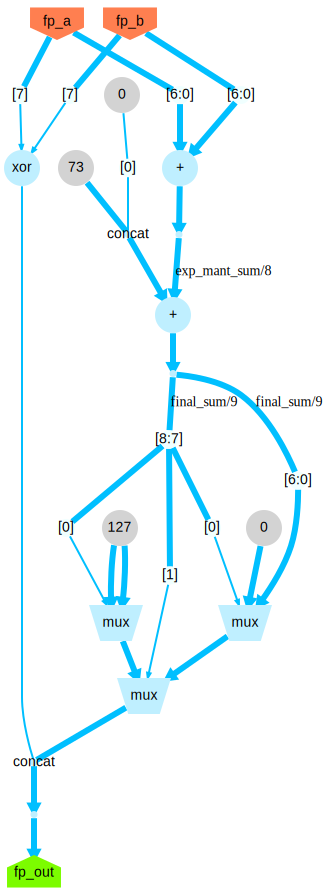

Pre Optimization:
The total block timing delay is  3025.0100000000007
Estimated Area of block 0.0004356 sq mm

Post Optimization:
The total block timing delay is  2580.84
Estimated Area of block 0.000233046 sq mm

Max frequency of block:  337.40012956164975 MHz


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 01001001
fp_a: 01110000 * fp_b: 01110000 = fp_out: 01111111
fp_a: 00000001 * fp_b: 00000001 = fp_out: 00000000
fp_a: 11000000 * fp_b: 01000000 = fp_out: 11001001
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000


In [ ]:
def lmul_naive():
    # Inputs 
    fp_a = pyrtl.Input(8, 'fp_a')
    fp_b = pyrtl.Input(8, 'fp_b')
    fp_out = pyrtl.Output(8, 'fp_out')

    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
    MAX_VALUE = pyrtl.Const(0x7F, 7)

    exp_mant_sum = pyrtl.WireVector(bitwidth=8, name='exp_mant_sum')
    final_sum = pyrtl.WireVector(bitwidth=9, name='final_sum')
    
    # Split into sign and exp_mantissa parts
    sign_a = fp_a[7] 
    sign_b = fp_b[7]
    exp_mantissa_a = fp_a[0:7]
    exp_mantissa_b = fp_b[0:7]

    # Calculate result sign
    result_sign = sign_a ^ sign_b
    
    exp_mant_sum <<= exp_mantissa_a + exp_mantissa_b
    final_sum <<= exp_mant_sum + OFFSET_MINUS_BIAS
    
    mantissa_result = pyrtl.mux(final_sum[7:], pyrtl.Const(0, bitwidth=7), final_sum[0:7], default=MAX_VALUE)

    # Combine sign and result
    fp_out <<= pyrtl.concat(result_sign, mantissa_result)

    return fp_a, fp_b, fp_out

analyze_circuit(lmul_naive, svg=True, display_pre_opt=True)

### FP8 Lmul Pipelined


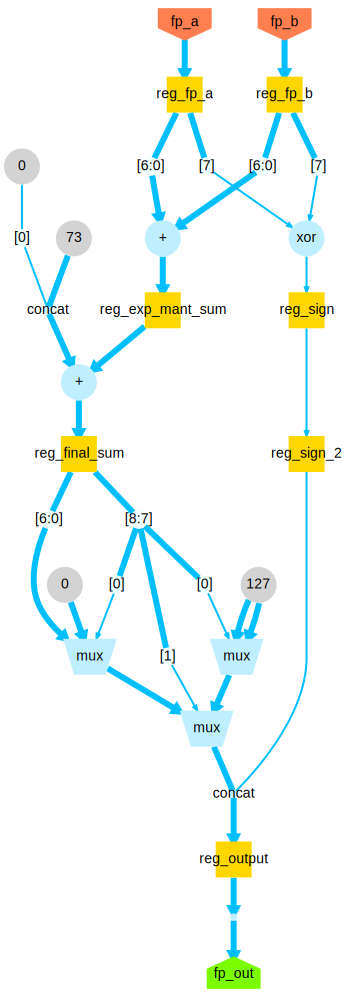

Pre Optimization:
The total block timing delay is  2472.8
Estimated Area of block 0.0007727544 sq mm

Post Optimization:
The total block timing delay is  1953.0999999999997
Estimated Area of block 0.0005702004 sq mm

Max frequency of block:  428.06386712897574 MHz


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 00000000
fp_a: 01110000 * fp_b: 01110000 = fp_out: 00000000
fp_a: 00000001 * fp_b: 00000001 = fp_out: 00000000
fp_a: 11000000 * fp_b: 01000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 01001001
fp_a: 00000000 * fp_b: 00000000 = fp_out: 01111111
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 11001001
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000


In [ ]:
class PipelinedLMUL:
    def __init__(self):
        # Inputs and Outputs
        self.fp_a = pyrtl.Input(8, 'fp_a')
        self.fp_b = pyrtl.Input(8, 'fp_b')
        self.fp_out = pyrtl.Output(8, 'fp_out')

        # Constants
        self.OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
        self.MAX_VALUE = pyrtl.Const(0x7F, 7)

        # Pipeline Registers
        # Stage 0 -> 1
        self.reg_fp_a = pyrtl.Register(8, 'reg_fp_a')
        self.reg_fp_b = pyrtl.Register(8, 'reg_fp_b')
        
        # Stage 1 -> 2
        self.reg_sign = pyrtl.Register(1, 'reg_sign')
        self.reg_exp_mant_sum = pyrtl.Register(8, 'reg_exp_mant_sum')
        
        # Stage 2 -> 3
        self.reg_final_sum = pyrtl.Register(9, 'reg_final_sum')
        self.reg_sign_2 = pyrtl.Register(1, 'reg_sign_2')
        
        # Stage 3 -> output
        self.reg_output = pyrtl.Register(8, 'reg_output')

        # Build pipeline
        self._build_pipeline()

    def stage0_input(self):
        """Input registration stage"""
        self.reg_fp_a.next <<= self.fp_a
        self.reg_fp_b.next <<= self.fp_b

    def stage1_split_and_add(self):
        """Split inputs and perform first addition"""
        # Split registered inputs
        sign_a = self.reg_fp_a[7]
        sign_b = self.reg_fp_b[7]
        exp_mantissa_a = self.reg_fp_a[0:7]
        exp_mantissa_b = self.reg_fp_b[0:7]
        
        # Calculate and register sign
        self.reg_sign.next <<= sign_a ^ sign_b
        
        # First addition and register result
        exp_mant_sum = exp_mantissa_a + exp_mantissa_b
        self.reg_exp_mant_sum.next <<= exp_mant_sum

    def stage2_offset_add(self):
        """Perform second addition with offset"""
        # Add offset and register result
        self.reg_final_sum.next <<= self.reg_exp_mant_sum + self.OFFSET_MINUS_BIAS
        # Pass through sign
        self.reg_sign_2.next <<= self.reg_sign

    def stage3_output_format(self):
        """Format final output"""
        # Mux selection based on overflow/underflow
        mantissa_result = pyrtl.mux(
            self.reg_final_sum[7:],  # Select bits for mux control
            pyrtl.Const(0, bitwidth=7),  # Underflow case
            self.reg_final_sum[0:7],  # Normal case
            default=self.MAX_VALUE  # Overflow case
        )
        
        # Combine sign and mantissa
        self.reg_output.next <<= pyrtl.concat(self.reg_sign_2, mantissa_result)

    def _build_pipeline(self):
        """Connect all pipeline stages"""
        self.stage0_input()
        self.stage1_split_and_add()
        self.stage2_offset_add()
        self.stage3_output_format()
        # Connect final register to output
        self.fp_out <<= self.reg_output

analyze_circuit(PipelinedLMUL, svg=True, display_pre_opt=True)

### Faster Pipelined LMUL


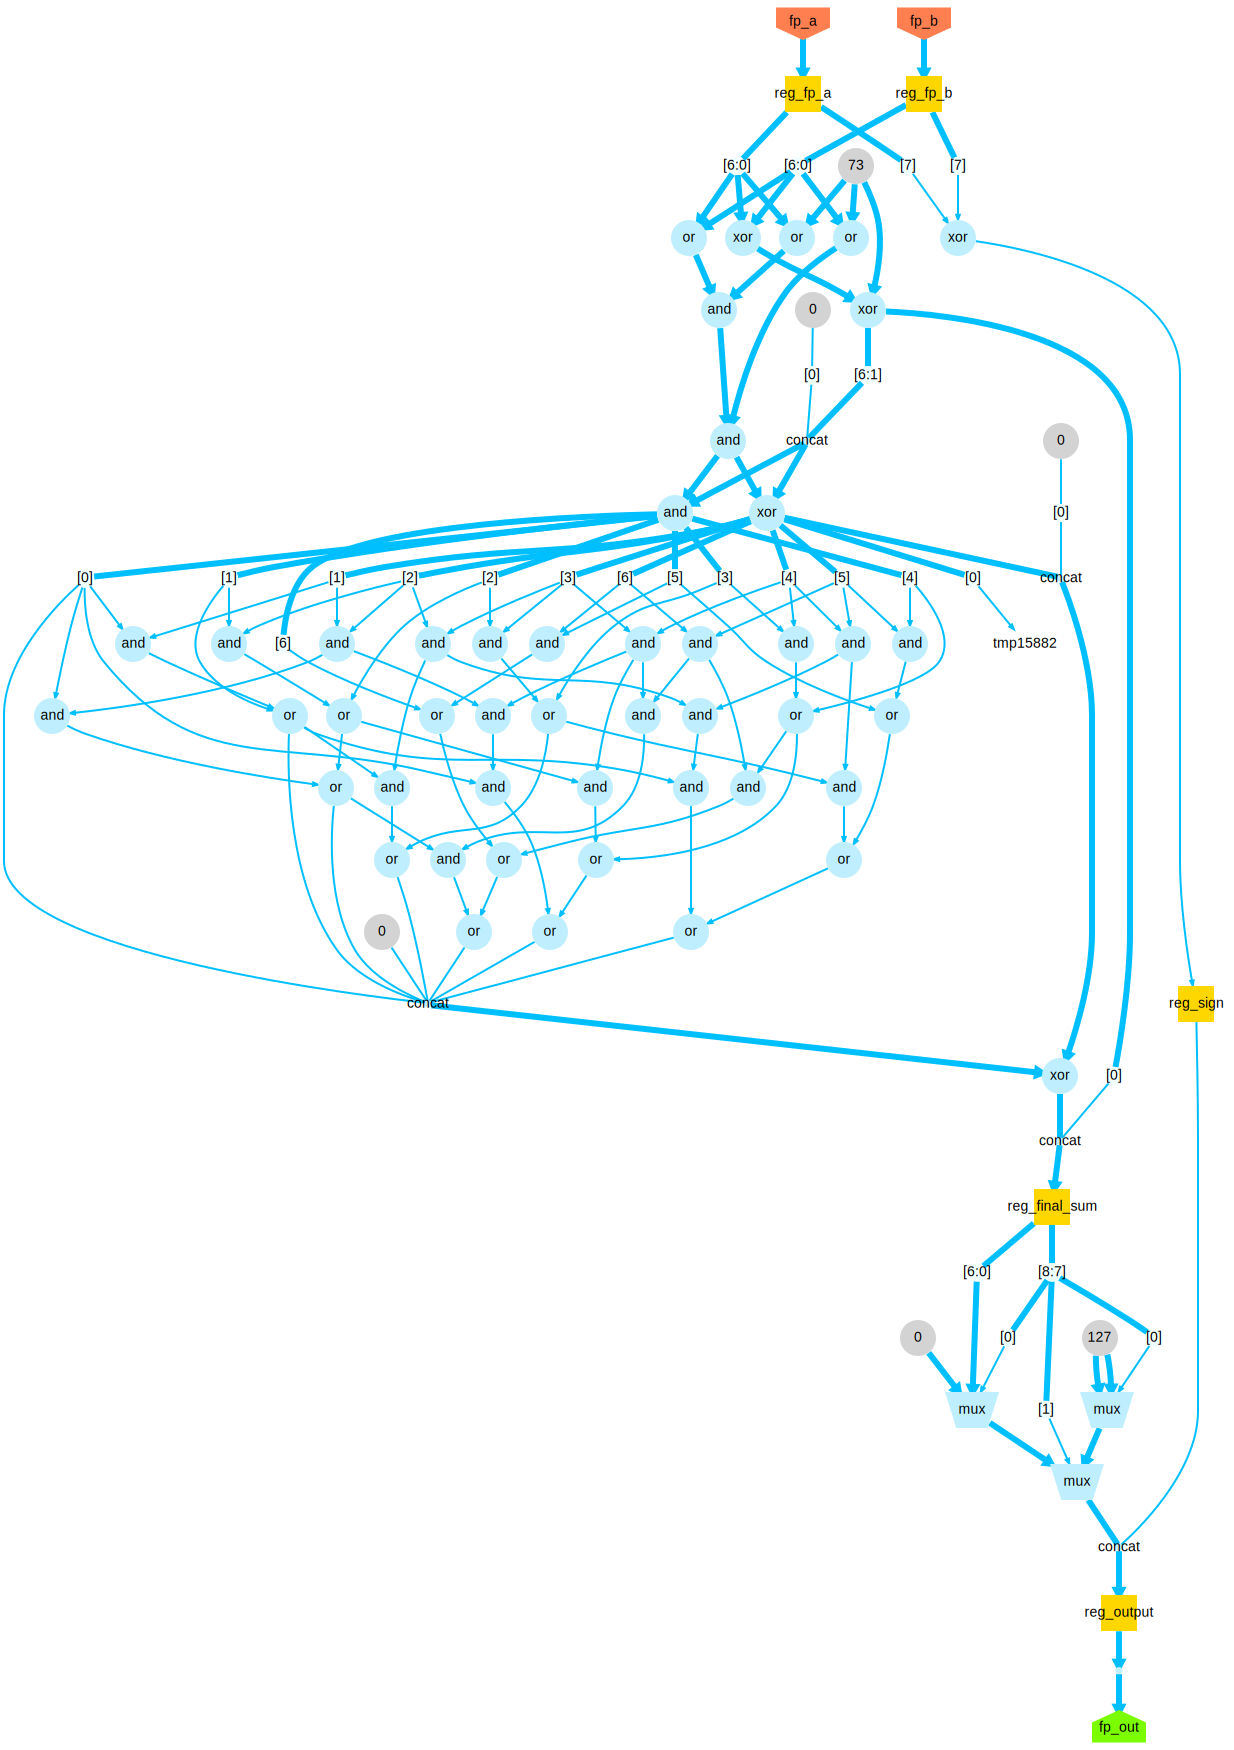

Pre Optimization:
The total block timing delay is  1085.34
Estimated Area of block 0.0007043652 sq mm

Post Optimization:
The total block timing delay is  1085.34
Estimated Area of block 0.0005257692 sq mm

Max frequency of block:  681.0411757494859 MHz


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 00000000
fp_a: 01110000 * fp_b: 01110000 = fp_out: 00000000
fp_a: 00000001 * fp_b: 00000001 = fp_out: 00000000
fp_a: 11000000 * fp_b: 01000000 = fp_out: 01001001
fp_a: 00000000 * fp_b: 00000000 = fp_out: 01111111
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 11001001
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000
fp_a: 00000000 * fp_b: 00000000 = fp_out: 00000000


In [ ]:
class FastPipelinedLMUL:
    def __init__(self):
        # Inputs and Outputs
        self.fp_a = pyrtl.Input(8, 'fp_a')
        self.fp_b = pyrtl.Input(8, 'fp_b')
        self.fp_out = pyrtl.Output(8, 'fp_out')

        # Constants
        self.OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
        self.MAX_VALUE = pyrtl.Const(0x7F, 7)

        # Pipeline Registers
        # Stage 0 -> 1
        self.reg_fp_a = pyrtl.Register(8, 'reg_fp_a')
        self.reg_fp_b = pyrtl.Register(8, 'reg_fp_b')
        
        # Stage 1 -> 2
        self.reg_sign = pyrtl.Register(1, 'reg_sign')
        self.reg_final_sum = pyrtl.Register(9, 'reg_final_sum')
        
        # Stage 2 -> output
        self.reg_output = pyrtl.Register(8, 'reg_output')

        # Build pipeline
        self._build_pipeline()

    def stage0_input(self):
        """Input registration stage"""
        self.reg_fp_a.next <<= self.fp_a
        self.reg_fp_b.next <<= self.fp_b

    def stage1_split_and_add(self):
        """Split inputs and perform additions"""
        # Split registered inputs
        sign_a = self.reg_fp_a[7]
        sign_b = self.reg_fp_b[7]
        exp_mantissa_a = self.reg_fp_a[0:7]
        exp_mantissa_b = self.reg_fp_b[0:7]
        
        # Calculate and register sign
        self.reg_sign.next <<= sign_a ^ sign_b
        
        # First addition and register result
        final_sum = carrysave_adder(
            exp_mantissa_a, 
            exp_mantissa_b, 
            self.OFFSET_MINUS_BIAS, 
            final_adder=kogge_stone
        )

        self.reg_final_sum.next <<= final_sum

    def stage2_output_format(self):
        """Format final output"""
        # Mux selection based on overflow/underflow
        mantissa_result = pyrtl.mux(
            self.reg_final_sum[7:],  # Select bits for mux control
            pyrtl.Const(0, bitwidth=7),  # Underflow case
            self.reg_final_sum[0:7],  # Normal case
            default=self.MAX_VALUE  # Overflow case
        )
        
        # Combine sign and mantissa
        self.reg_output.next <<= pyrtl.concat(self.reg_sign, mantissa_result)

    def _build_pipeline(self):
        """Connect all pipeline stages"""
        self.stage0_input()
        self.stage1_split_and_add()
        self.stage2_output_format()
        # Connect final register to output
        self.fp_out <<= self.reg_output

analyze_circuit(FastPipelinedLMUL, svg=True, display_pre_opt=True)

### FP8 Lmul with WireStruct


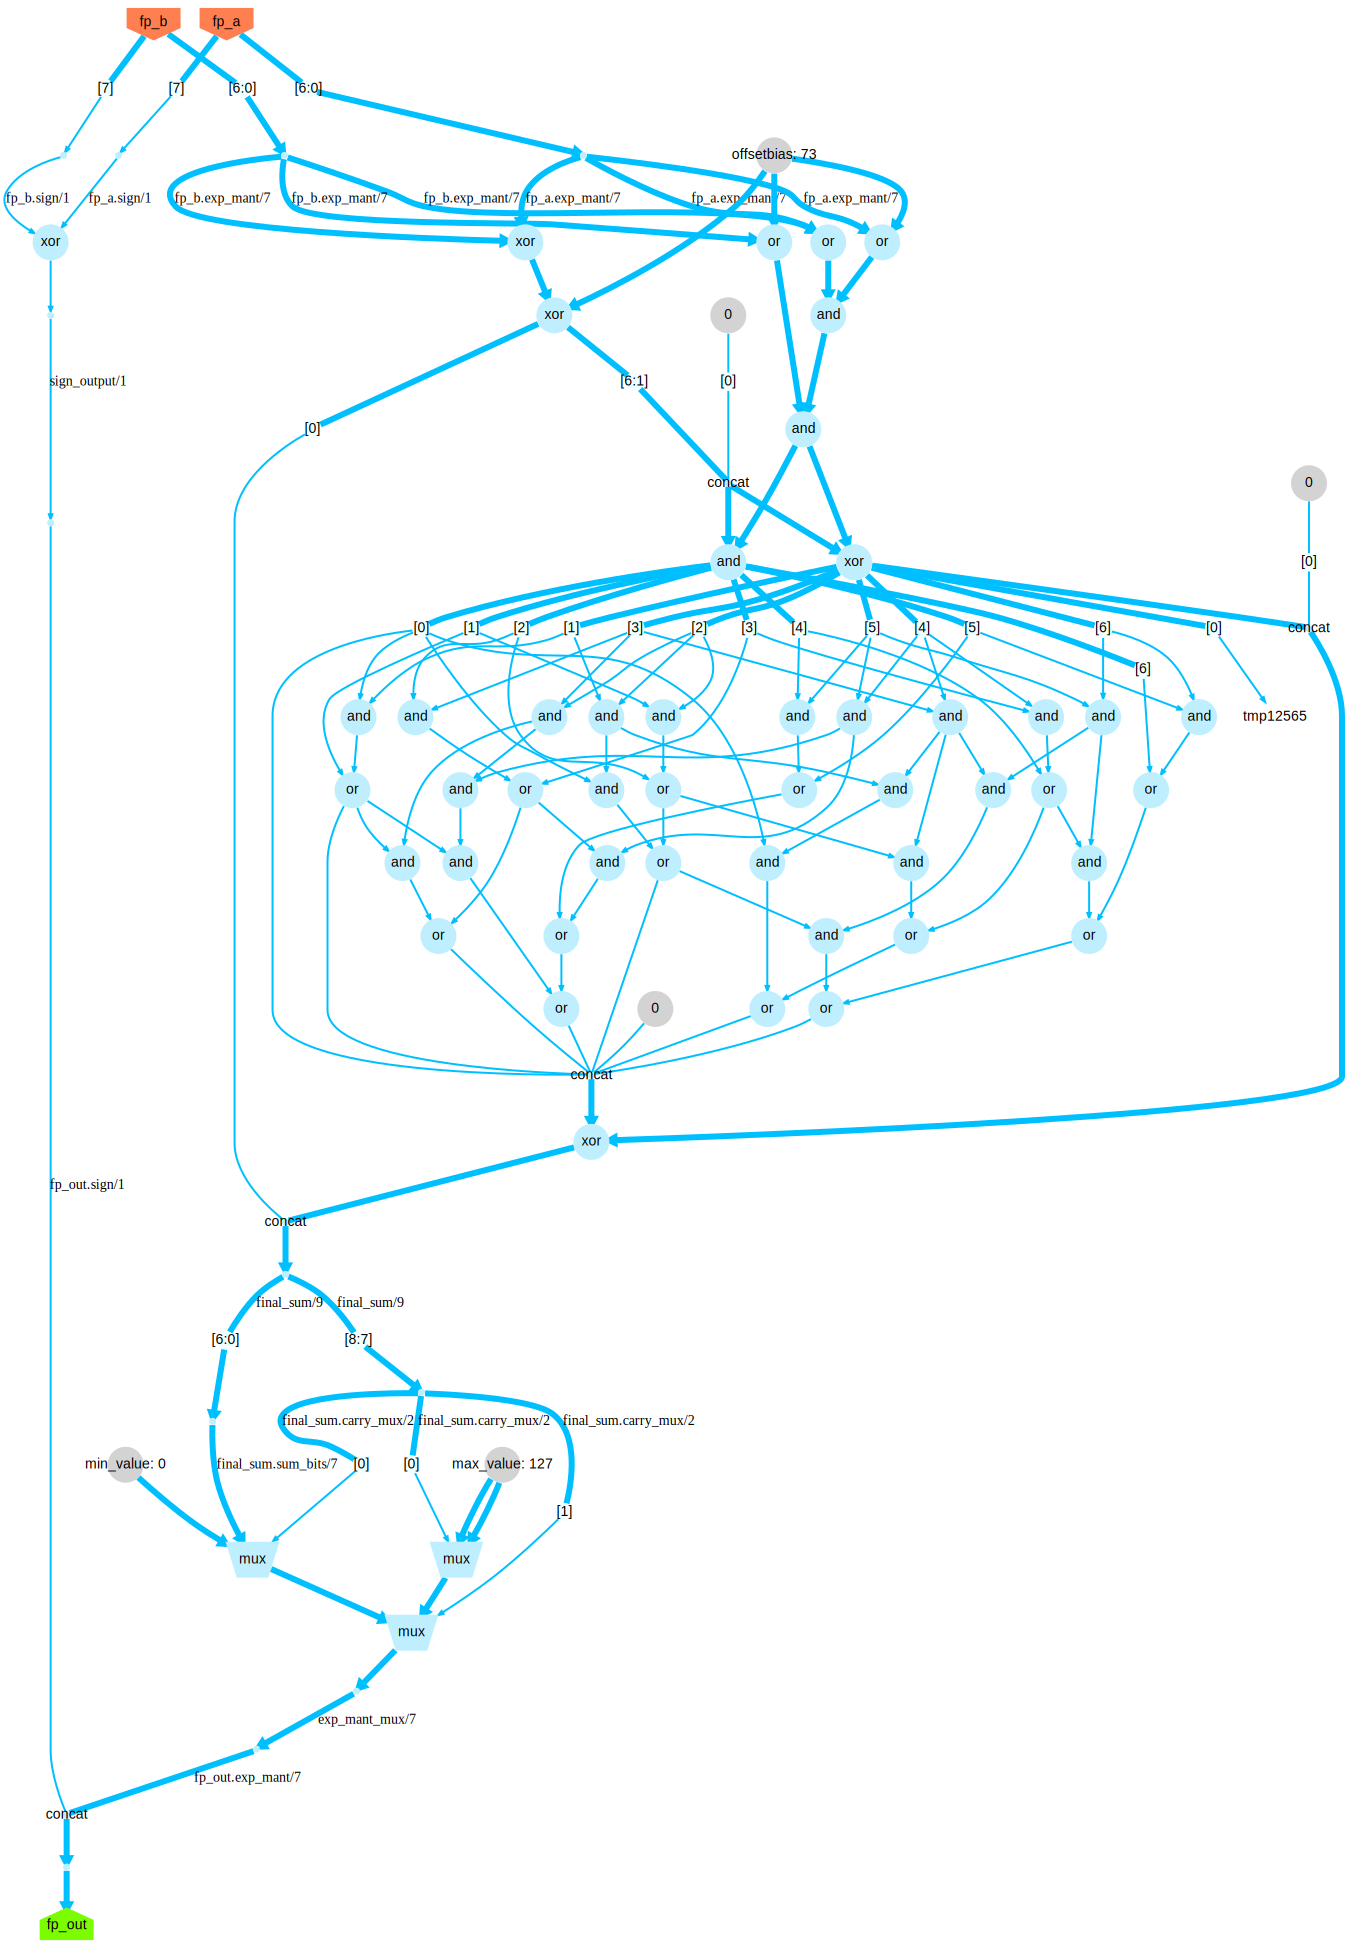

Pre Optimization:
The total block timing delay is  1541.4399999999998
Estimated Area of block 0.000437778 sq mm

Post Optimization:
The total block timing delay is  1406.37
Estimated Area of block 0.000259182 sq mm

Max frequency of block:  558.8559101806782 MHz


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 01001001
fp_a: 01110000 * fp_b: 01110000 = fp_out: 01111111
fp_a: 00000001 * fp_b: 00000001 = fp_out: 00000000
fp_a: 11000000 * fp_b: 01000000 = fp_out: 11001001


In [ ]:
@pyrtl.wire_struct
class FP8:
    sign: 1
    exp_mant: 7

@pyrtl.wire_struct
class FP8_LMUL_SUM:
    carry_mux: 2
    sum_bits: 7


def lmul_struct():
    # Inputs 
    fp_a = FP8(name='fp_a', concatenated_type=pyrtl.Input)
    fp_b = FP8(name='fp_b', concatenated_type=pyrtl.Input)
    
    # Calculate result sign
    sign_output = pyrtl.WireVector(1, name='sign_output')
    sign_output <<= fp_a.sign ^ fp_b.sign

    # Add exp_mantissa parts using kogge_stone adder (faster than ripple)
    # exp_mantissa_sum = kogge_stone(exp_mantissa_a, exp_mantissa_b)
    
    # For E4M3: e_bits=4, m_bits=3
    # Get the combined offset-bias constant 
    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7, name='offsetbias')
    
    # Add offset-bias value - this will be 8 bits including carry
    # final_sum = kogge_stone(exp_mantissa_sum, OFFSET_MINUS_BIAS)
    
    final_sum = FP8_LMUL_SUM(
        name='final_sum', 
        FP8_LMUL_SUM=carrysave_adder(
            fp_a.exp_mant, 
            fp_b.exp_mant, 
            OFFSET_MINUS_BIAS, 
            final_adder=kogge_stone
        )
    )

    MIN_VALUE = pyrtl.Const(0, bitwidth=7, name='min_value')
    MAX_VALUE = pyrtl.Const(0x7F, bitwidth=7, name='max_value')
    
    exp_mant = pyrtl.WireVector(7, name='exp_mant_mux')
    exp_mant <<= pyrtl.mux(
        final_sum.carry_mux, 
        MIN_VALUE, 
        final_sum.sum_bits, 
        default=MAX_VALUE,
    )

    fp_out = FP8(
        name='fp_out', 
        sign=sign_output, 
        exp_mant=exp_mant, 
        concatenated_type=pyrtl.Output
    )

    return fp_a, fp_b, fp_out

analyze_circuit(lmul_struct, svg=True, display_pre_opt=True)

### Dynamic Precision Lmul


#### Floating Point Format Helpers


In [ ]:
def get_float_constants(exp_bits: int, mant_bits: int) -> dict:
    """
    Generate floating point format constants based on exponent and mantissa bits.
    
    Args:
        exp_bits: Number of exponent bits
        mant_bits: Number of mantissa bits
        
    Returns:
        Dictionary containing format constants including:
        - Special values (nan, inf, zero etc)
        - Max/min normal values
        - Format specifications
    """
    total_bits = 1 + exp_bits + mant_bits  # sign + exp + mant
    
    # Calculate key bit patterns
    exp_mask = ((1 << exp_bits) - 1) << mant_bits
    mant_mask = (1 << mant_bits) - 1
    sign_bit = 1 << (total_bits - 1)
    
    # Special exponent values
    exp_bias = (1 << (exp_bits - 1)) - 1
    exp_all_ones = (1 << exp_bits) - 1
    
    # Calculate constants
    constants = {
        'nan': (exp_all_ones << mant_bits) | (1 << (mant_bits-1)),  # Exponent all 1s, MSB of mantissa 1
        'inf': exp_all_ones << mant_bits,  # Exponent all 1s, mantissa 0
        'neg_inf': sign_bit | (exp_all_ones << mant_bits),  # Sign 1, exponent all 1s, mantissa 0
        'zero': 0x0,  # All bits 0
        'neg_zero': sign_bit,  # Sign 1, all else 0
        
        # Max values use all 1s in mantissa and max normal exponent
        'max_pos': ((exp_all_ones - 1) << mant_bits) | mant_mask,
        'max_neg': sign_bit | ((exp_all_ones - 1) << mant_bits) | mant_mask,
        
        # Min normal values use minimum normal exponent (1) and 0 mantissa
        'min_pos': 1 << mant_bits,
        'min_neg': sign_bit | (1 << mant_bits),
        
        # Format specifications
        'bits': total_bits,
        'exponent_bits': exp_bits,
        'mantissa_bits': mant_bits,
        'exponent_bias': exp_bias
    }
    
    return constants


# Common formats
bf16 = get_float_constants(8, 7)    # bfloat16
fp16 = get_float_constants(5, 10)   # IEEE half precision
fp8e4m3 = get_float_constants(4, 3) # 8-bit float with 4 exp, 3 mantissa
fp32 = get_float_constants(8, 23)   # IEEE single precision

{k: format(v, '016b') for k, v in bf16.items()}
{k: format(v, '08b') for k, v in fp8e4m3.items()}

{'nan': '01111100',
 'inf': '01111000',
 'neg_inf': '11111000',
 'zero': '00000000',
 'neg_zero': '10000000',
 'max_pos': '01110111',
 'max_neg': '11110111',
 'min_pos': '00001000',
 'min_neg': '10001000',
 'bits': '00001000',
 'exponent_bits': '00000100',
 'mantissa_bits': '00000011',
 'exponent_bias': '00000111'}

#### Dynamic Lmul PyRTL Implementation


Pre Optimization:
The total block timing delay is  1541.4399999999998
Estimated Area of block 0.000437778 sq mm

Post Optimization:
The total block timing delay is  1406.37
Estimated Area of block 0.000259182 sq mm



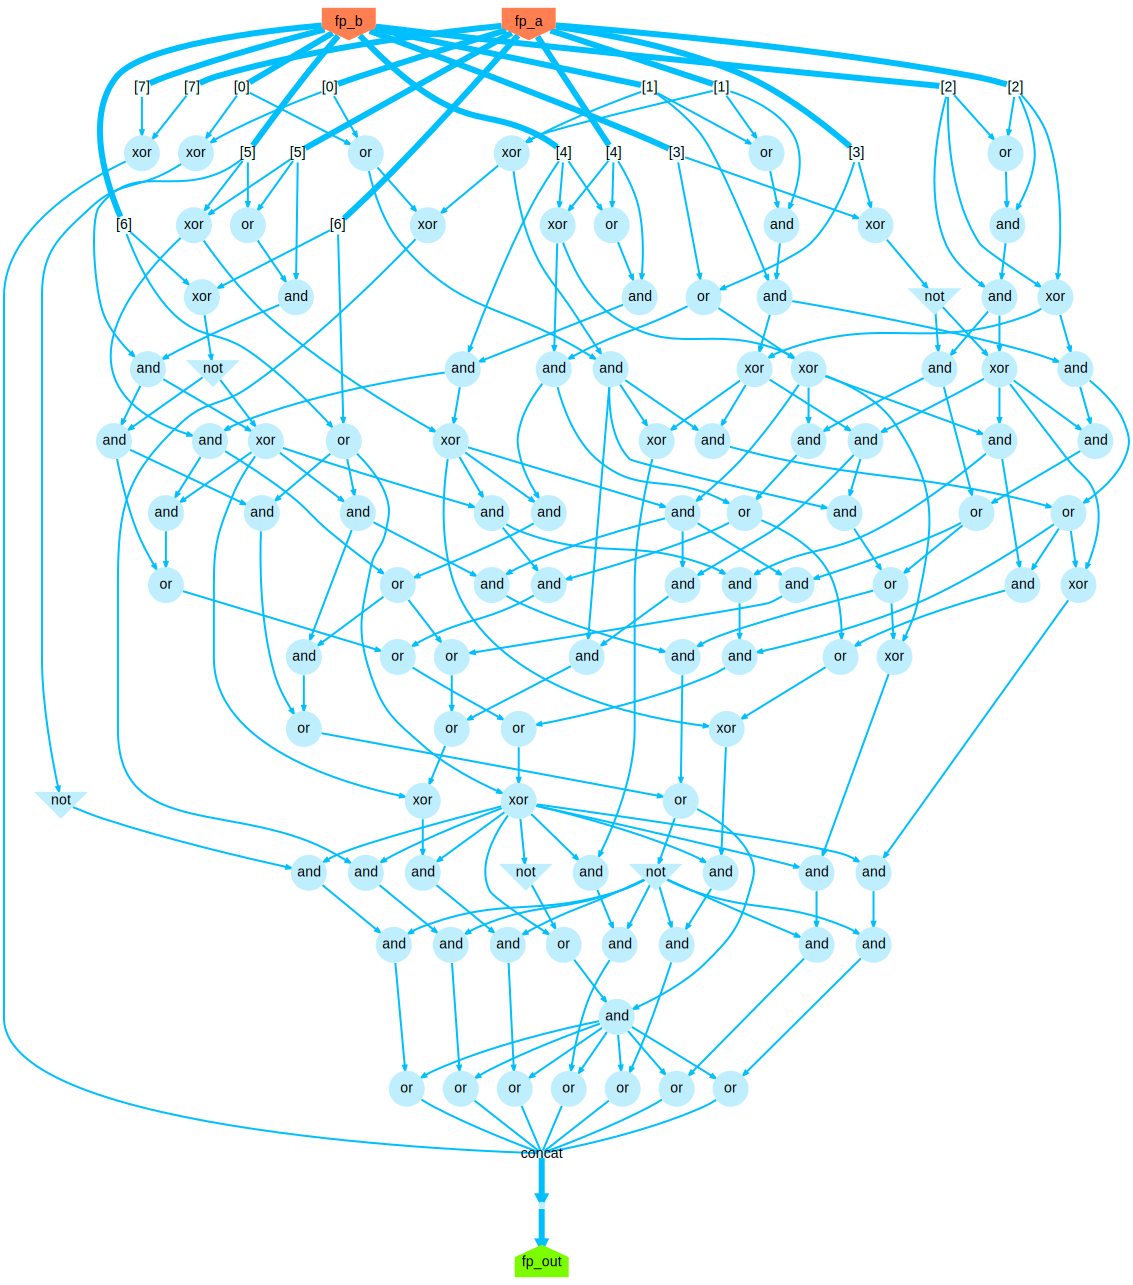

In [ ]:
def lmul_dynamic(EXP_BITS, MANT_BITS):
    exp_mant_bits = EXP_BITS + MANT_BITS
    total_bits = 1 + exp_mant_bits
    # Inputs 
    fp_a = pyrtl.Input(total_bits, 'fp_a')
    fp_b = pyrtl.Input(total_bits, 'fp_b')
    fp_out = pyrtl.Output(total_bits, 'fp_out')

    # Split into sign and exp_mantissa parts
    sign_a = fp_a[exp_mant_bits] 
    sign_b = fp_b[exp_mant_bits]
    exp_mantissa_a = fp_a[0:exp_mant_bits]
    exp_mantissa_b = fp_b[0:exp_mant_bits]

    # Calculate result sign
    result_sign = sign_a ^ sign_b

    # Add exp_mantissa parts using kogge_stone adder (faster than ripple)
    # exp_mantissa_sum = kogge_stone(exp_mantissa_a, exp_mantissa_b)
    
    # For E4M3: e_bits=4, m_bits=3
    # Get the combined offset-bias constant 
    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(EXP_BITS, MANT_BITS), bitwidth=exp_mant_bits)
    
    # Add offset-bias value - this will be 8 bits including carry
    # final_sum = kogge_stone(exp_mantissa_sum, OFFSET_MINUS_BIAS)
    
    final_sum = carrysave_adder(exp_mantissa_a, exp_mantissa_b, OFFSET_MINUS_BIAS, final_adder=kogge_stone)
    # Extract carry and MSB for overflow/underflow detection
    # mux_in = final_sum[7:]  # 8th and 9th bits
    # result_bits = final_sum[0:7]  # lower 7 bits

    # Select result based on carry and MSB:
    # carry=1: overflow -> 0x7F
    # carry=0, msb=0: underflow -> 0x00
    # carry=0, msb=1: normal -> result_bits
    MAX_VALUE = pyrtl.Const(get_ma, 7)
    
    mantissa_result = pyrtl.mux(final_sum[7:], pyrtl.Const(0, bitwidth=7), final_sum[0:7], default=MAX_VALUE)

    # Combine sign and result
    fp_out <<= pyrtl.concat(result_sign, mantissa_result)

    return fp_a, fp_b, fp_out

# Create the hardware
pyrtl.reset_working_block()
fp_a, fp_b, fp_out = lmul_rtl()

pyrtl.synthesize()

# Generating timing analysis information
print("Pre Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()
logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=65)
est_area = logic_area + mem_area
print("Estimated Area of block", est_area, "sq mm")
print()

pyrtl.optimize()

print("Post Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()
logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=65)
est_area = logic_area + mem_area
print("Estimated Area of block", est_area, "sq mm")
print()

svg = pyrtl.block_to_svg()
display_svg(svg, raw=True)

### Pipelining


In [ ]:
""" Example 5: Making use of PyRTL and Introspection. """

import pyrtl


# The following example shows how PyRTL can be used to make some interesting
# hardware structures using Python introspection.  In particular, this example
# makes a N-stage pipeline structure.  Any specific pipeline is then a derived
# class of SimplePipeline where methods with names starting with "stage" are
# stages, and new members with names not starting with "_" are to be registered
# for the next stage.

class SimplePipeline(object):
    """ Pipeline builder with auto generation of pipeline registers. """

    def __init__(self):
        self._pipeline_register_map = {}
        self._current_stage_num = 0
        stage_list = [method for method in dir(self) if method.startswith('stage')]
        for stage in sorted(stage_list):
            stage_method = getattr(self, stage)
            stage_method()
            self._current_stage_num += 1

    def __getattr__(self, name):
        try:
            return self._pipeline_register_map[self._current_stage_num][name]
        except KeyError:
            raise pyrtl.PyrtlError(
                'error, no pipeline register "%s" defined for stage %d'
                % (name, self._current_stage_num))

    def __setattr__(self, name, value):
        if name.startswith('_'):
            # do not do anything tricky with variables starting with '_'
            object.__setattr__(self, name, value)
        else:
            next_stage = self._current_stage_num + 1
            pipereg_id = str(self._current_stage_num) + 'to' + str(next_stage)
            rname = 'pipereg_' + pipereg_id + '_' + name
            new_pipereg = pyrtl.Register(bitwidth=len(value), name=rname)
            if next_stage not in self._pipeline_register_map:
                self._pipeline_register_map[next_stage] = {}
            self._pipeline_register_map[next_stage][name] = new_pipereg
            new_pipereg.next <<= value

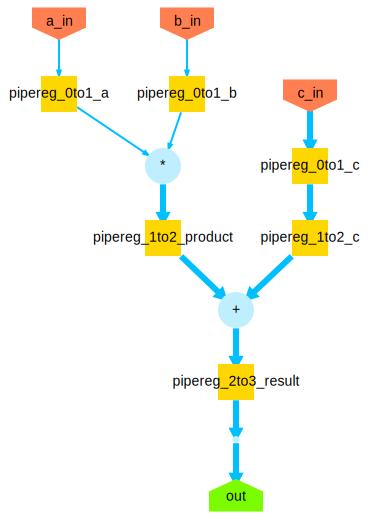

In [ ]:
pyrtl.reset_working_block()

class FloatingPointMAC(SimplePipeline):
    def __init__(self):
        self._out = pyrtl.Output(3, 'out')
        super(FloatingPointMAC, self).__init__()
    def stage0(self):
        # Input stage - receive operands
        self.a = pyrtl.Input(1, 'a_in')
        self.b = pyrtl.Input(1, 'b_in')
        self.c =  pyrtl.Input(2, 'c_in')

    def stage1(self):
        # Multiply stage
        self.product = self.a * self.b
        self.c = self.c  # Pass through c to next stage

    def stage2(self):
        # Add stage
        self.result = self.product + self.c

    def stage3(self):
        # Output stage
        self._out <<= self.result

simplepipeline = FloatingPointMAC()
svg = pyrtl.block_to_svg(split_state=False)
display_svg(svg, raw=True)

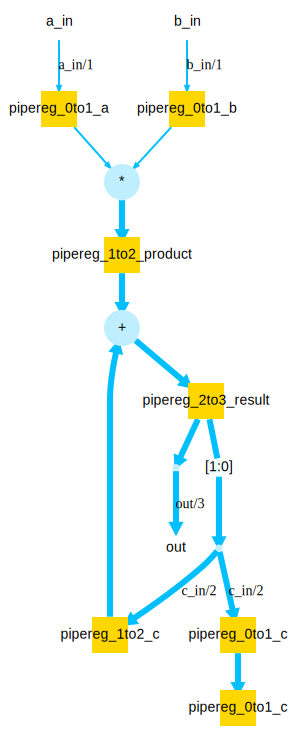

In [ ]:
pyrtl.reset_working_block()

class FloatingPointMAC(SimplePipeline):
    def __init__(self):
        self._out = pyrtl.WireVector(3, 'out')
        self._a = pyrtl.WireVector(1, 'a_in')
        self._b = pyrtl.WireVector(1, 'b_in')
        self._c =  pyrtl.WireVector(2, 'c_in')
        super(FloatingPointMAC, self).__init__()
        
    def stage0(self):
        # Input stage - receive operands
        # self.a = pyrtl.Input(1, 'a_in')
        # self.b = pyrtl.Input(1, 'b_in')
        # self.c =  pyrtl.Input(2, 'c_in')

        self.a = self._a
        self.b = self._b
        self.c = self._c

    def stage1(self):
        # Multiply stage
        self.product = self.a * self.b
        # self.c = self.c  # Pass through c to next stage

        # self.product = self._a * self._b
        self.c = self._c  # Pass through c to next stage

    def stage2(self):
        # Add stage
        
        self.result = self.product + self.c
        # self._c <<= self.result

    def stage3(self):
        # Output stage
        # global out
        self._out <<= self.result
        self._c <<= self.result

simplepipeline = FloatingPointMAC()
svg = pyrtl.block_to_svg(split_state=False)
display_svg(svg, raw=True)

In [ ]:
0xc

12

<IPython.core.display.Latex object>

<IPython.core.display.Javascript object>

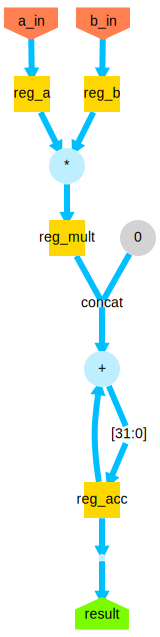

In [ ]:
import pyrtl

# Reset working block
pyrtl.reset_working_block()

# Input/Output declarations
a_in = pyrtl.Input(8, 'a_in')
b_in = pyrtl.Input(8, 'b_in')
# reset = pyrtl.Input(1, 'reset')
result = pyrtl.Output(32, 'result')

class PipelinedMAC:
    def __init__(self):
        # Stage 0 -> 1: Input registers
        self.reg_a = pyrtl.Register(8, 'reg_a')
        self.reg_b = pyrtl.Register(8, 'reg_b')
        
        # Stage 1 -> 2: Multiplication result register
        self.reg_mult = pyrtl.Register(16, 'reg_mult')
        
        # Stage 2: Accumulator register
        self.reg_acc = pyrtl.Register(32, 'reg_acc')
        
        # Build the pipeline
        self._build_pipeline()
    
    def _build_pipeline(self):
        # Stage 0: Register inputs
        self.reg_a.next <<= a_in
        self.reg_b.next <<= b_in
        
        # Stage 1: Multiplication
        mult_result = self.reg_a * self.reg_b  # 8x8 = 16 bits
        self.reg_mult.next <<= mult_result
        
        # Stage 2: Accumulation
        # Zero extend multiplication result to 32 bits
        extended_mult = pyrtl.concat(pyrtl.Const(0, 16), self.reg_mult)
        
        # Create accumulator logic with reset
        self.reg_acc.next <<= self.reg_acc + extended_mult
        global result
        # Connect accumulator to output
        result <<= self.reg_acc

# Instantiate the MAC unit
mac = PipelinedMAC()

# Optional: Print the working block to see the design
print(pyrtl.working_block())

# Optional: Add simulation code for testing
if __name__ == '__main__':
    sim = pyrtl.Simulation()
    
    # Test vectors
    sim_inputs = {
        'a_in':    [1, 2, 3, 0, 0, 0],
        'b_in':    [2, 3, 4, 0, 0, 0],
        # 'reset':   [0, 0, 0, 0, 0]  # Reset first cycle only
    }
    
    # Run simulation
    sim.step_multiple(sim_inputs)
    
    # Display trace
    sim.tracer.render_trace()
    svg = pyrtl.block_to_svg(split_state=False)
    display_svg(svg, raw=True)


### Floating Point Adder


In [ ]:
import pyrtl
from pyrtl import conditional_assignment

# First, let's create a wire_struct for floating point numbers
@pyrtl.wire_struct
class Float32:
    sign: 1
    exponent: 8
    mantissa: 23

class FloatAdder:
    def __init__(self):
        # Input/Output declarations
        self.operand1 = Float32(name='operand1', concatenated_type=pyrtl.Input)
        self.operand2 = Float32(name='operand2', concatenated_type=pyrtl.Input)
        self.sign_out = pyrtl.WireVector(1, name='sign_out')
        self.exponent_out = pyrtl.WireVector(8, name='exponent_out')
        self.mantissa_out = pyrtl.WireVector(23, name='mantissa_out')
        
        # Pipeline control signals
        self.busy1 = pyrtl.Register(1, 'busy1')
        self.busy2 = pyrtl.Register(1, 'busy2')
        self.busy3 = pyrtl.Register(1, 'busy3')
        self.done1 = pyrtl.WireVector(1, 'done1')
        self.done2 = pyrtl.WireVector(1, 'done2')
        self.done3 = pyrtl.WireVector(1, 'done3')

        # Internal registers for pipeline stages
        self.mantissa1_reg = pyrtl.Register(24, 'mantissa1_reg')  # 23 + hidden bit
        self.mantissa2_reg = pyrtl.Register(24, 'mantissa2_reg')
        self.exponent1_reg = pyrtl.Register(8, 'exponent1_reg')
        self.exponent2_reg = pyrtl.Register(8, 'exponent2_reg')
        
        # Stage 1: Compare and Shift registers
        self.shifted_mantissa1 = pyrtl.Register(24, 'shifted_mantissa1')
        self.shifted_mantissa2 = pyrtl.Register(24, 'shifted_mantissa2')
        self.new_exponent = pyrtl.Register(8, 'new_exponent')
        
        # Stage 2: Addition registers
        self.mantissa_sum = pyrtl.Register(25, 'mantissa_sum')  # Extra bit for overflow
        
        # Stage 3: Normalization registers
        self.final_mantissa = pyrtl.Register(24, 'final_mantissa')
        self.final_exponent = pyrtl.Register(8, 'final_exponent')
        
        # Build the pipeline
        self._build_pipeline()

    def _compare_and_shift(self):
        """Stage 1: Compare exponents and shift mantissas"""
        with conditional_assignment:
            with ~self.busy1:
                # Load new values
                self.mantissa1_reg.next |= pyrtl.concat(pyrtl.Const(1, 1), self.operand1.mantissa)
                self.mantissa2_reg.next |= pyrtl.concat(pyrtl.Const(1, 1), self.operand2.mantissa)
                self.exponent1_reg.next |= self.operand1.exponent
                self.exponent2_reg.next |= self.operand2.exponent
                self.busy1.next |= 1

            with self.busy1:
                # Compare exponents and shift mantissas
                exp_diff = self.exponent1_reg - self.exponent2_reg
                exp_1_greater = self.exponent1_reg > self.exponent2_reg
                
                with exp_1_greater:
                    self.shifted_mantissa1.next |= self.mantissa1_reg
                    self.shifted_mantissa2.next |= pyrtl.shift_right_logical(self.mantissa2_reg, exp_diff)
                    self.new_exponent.next |= self.exponent1_reg + 1
                
                with ~exp_1_greater:
                    diff = self.exponent2_reg - self.exponent1_reg
                    self.shifted_mantissa2.next |= self.mantissa2_reg
                    self.shifted_mantissa1.next |= pyrtl.shift_right_logical(self.mantissa1_reg, diff)
                    self.new_exponent.next |= self.exponent2_reg + 1
                
                self.done1 |= 1
                self.busy1.next |= 0

    def _add_mantissas(self):
        """Stage 2: Add the aligned mantissas"""
        with conditional_assignment:
            with self.done1 & ~self.busy2:
                self.mantissa_sum.next |= self.shifted_mantissa1 + self.shifted_mantissa2
                self.busy2.next |= 1
                self.done2 |= 1
                self.busy2.next |= 0

    def _normalize(self):
        """Stage 3: Normalize the result"""
        with conditional_assignment:
            with self.done2 & ~self.busy3:
                # Initial normalization
                self.final_mantissa.next |= self.mantissa_sum[24:1]
                self.final_exponent.next |= self.new_exponent
                self.busy3.next |= 1

            with self.busy3:
                # Normalize until leading 1
                leading_zero = ~self.final_mantissa[23]
                with leading_zero:
                    self.final_mantissa.next |= pyrtl.shift_left_logical(self.final_mantissa, 1)
                    self.final_exponent.next |= self.final_exponent - 1
                with ~leading_zero:
                    self.done3 |= 1
                    self.busy3.next |= 0

    def _build_pipeline(self):
        """Connect all pipeline stages"""
        self._compare_and_shift()
        self._add_mantissas()
        self._normalize()
        
        # Connect final output
        with conditional_assignment:
            with self.done3:
                self.sign_out |= self.operand1.sign  # Simplified - should handle sign properly
                self.exponent_out |= self.final_exponent
                self.mantissa_out |= self.final_mantissa[22:0]
                # self.sum_out = Float32(sign=self.sign_out, exponent=self.exponent_out, mantissa=self.mantissa_out)

def test_float_adder():
    # Create the adder
    adder = FloatAdder()
    
    # Create simulation
    sim_trace = pyrtl.SimulationTrace()
    sim = pyrtl.Simulation(tracer=sim_trace)
    
    # Test vectors
    test_cases = [
        # op1: (sign, exp, mantissa), op2: (sign, exp, mantissa)
        ((0, 0x7F, 0), (0, 0x7F, 0)),  # 1.0 + 1.0
        ((0, 0x80, 0), (0, 0x7F, 0)),  # 2.0 + 1.0
    ]
    
    for op1, op2 in test_cases:
        # Create input dictionary
        sim.step({
            'operand1': pyrtl.concat_list([op1[0], op1[1], op1[2]]),
            'operand2': pyrtl.concat_list([op2[0], op2[1], op2[2]])
        })
    
    # Display the trace
    sim_trace.render_trace()

if __name__ == "__main__":
    test_float_adder()


PyrtlInternalError: error, net op "x" not from acceptable set {'~', 'r', 'w', 's', 'c', 'm', '^', '@', '|', '&', 'n'}